# Stangenmechanisme: Pantograaf met Chebyshev-aandrijving

Dit notebook analyseert de kinematica van een **pantograafmechanisme dat aangedreven wordt door een Chebyshev-linkage**. Hetzelfde mechanisme wordt gebruikt in het *touwbeest* (geïnspireerd op Theo Jansens *strandbeest*): vier identieke pantograafbenen, paarsgewijs in tegenfase, voor een loopcyclus van een wandelende robot.

**Topologie**

- Vaste punten: $A$, $B$ (Chebyshev-frame) en $E$ (vaste pantograafpivot).
- Eerste vierstang: $A\text{-}C\text{-}D\text{-}B$. De inputstang $AC$ is de **volledig roterende kruk** (Grashof rocker-kruk).
- Verlengde coupler: $C\text{-}D\text{-}G$. Het punt $G$ drijft het pantograafdeel aan.
- Pantograaf: parallelogram $G\text{-}F\text{-}H\text{-}I$ met rocker $E\text{-}F\text{-}H$.
- Uitgang: $End$, collineair met $H\text{-}I$ aan de overzijde van $I$.

**Werkwijze**

1. Geometrie en parameters vastleggen.
2. Mobiliteit numeriek verifiëren via de Chebychev–Grübler–Kutzbach-formule.
3. Sluitingsvergelijkingen afleiden (3 lussen × 2 = 6 vergelijkingen, 6 onbekenden).
4. Positie-analyse met `fsolve` (hoofdmethode) en met **cirkelsneden** (kruiscontrole).
5. Snelheids- en versnellingsanalyse via de afgeleide sluitingsvergelijkingen.
6. Lineaire snelheid/versnelling van interessante punten + numerieke afgeleide als check.
7. Plots, animatie en singulariteitsanalyse.


## 1. Kinematisch diagram

<img src="assets/kinematic_diagram_reference.png" alt="Kinematisch diagram met stang- en hoeknotatie" width="760">

Het kinematisch diagram toont:

- de **vaste punten** $A$, $B$, $E$ (zwarte vierkanten);
- de **inputstang** $AC$ (roterende kruk, lengte $r_1$);
- de **Chebyshev-coupler** $CDG$ (rigide stang met lengtes $\ell_{41}$ en $\ell_{42}$);
- de **rocker** $BD$ (lengte $r_2$);
- het **pantograafparallelogram** $GFHI$ met $|GF|=|HI|=r_3$ en $|FH|=|GI|=\ell_{52}$;
- de **pantograafrocker** $EFH$ (rigide stang met lengtes $\ell_{51}$ en $\ell_{52}$);
- de **uitgangsarm** $H\text{-}I\text{-}End$ (rigide stang, $|HI|=r_3$, $|I\text{-}End|=r_7$).

De **pantograafwet** $r_7 = \ell_{52}\cdot r_3 / \ell_{51}$ dwingt $E$, $G$ en $End$ collineair af, zodat $End$ een **vergrote afbeelding** is van het traject van $G$, met versterkingsfactor $1 + \ell_{52}/\ell_{51}$.


In [59]:
# Bron: standaard imports (Linkage_Project (3).ipynb, cel 3) + matplotlib animation
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import fsolve
from IPython.display import HTML

matplotlib.rcParams["animation.embed_limit"] = 100  # MB, voor lange animaties

def deg_to_rad(deg):
    return deg * np.pi / 180.0

def rad_to_deg(rad):
    return rad * 180.0 / np.pi

def rotate_vector(z, theta):
    '''Roteer een 2D-vector z over een hoek theta (radialen).
    Bron: Linkage_Project (3).ipynb, cel 10.'''
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return R @ np.asarray(z, dtype=float)

from IPython.display import HTML, display

# display(HTML(
#     '<img src="assets/kinematic_diagram_reference.png" style="width:20%;">'
# ))

## 2. Geometrie van het mechanisme

<div style="display: flex; gap: 24px; align-items: flex-start;">

<div style="flex: 1.15; min-width: 0;">

- pantograafverhouding (versterking $= 1 + \ell_{52}/\ell_{51} = 4$). 
- het mechanisme komt overeen met onze touwbeest-toepassing van ongeveer 1.5 m verticale slag aan het uiteinde.

**Vaste punten en vaste afstanden**

| grootheid | betekenis | waarde |
|---|---|---:|
| $A$ | scharnier kruk | $(0,\,0)$ m |
| $B$ | scharnier rocker | $(d_1,\,0)$ m |
| $E$ | scharnier pantograafrocker | $(d_1+d_2,\,-d_3)$ m |
| $d_1$ | afstand $A\!\to\!B$ | $0.200$ m |
| $d_2$ | horizontale offset $B\!\to\!E$ | $0.080$ m |
| $d_3$ | verticale offset onder $B$ | $0.120$ m |

**Stangen en lengtes**

| onderdeel | punten | symbool | lengte |
|---|---|---|---:|
| inputkruk | $AC$ | $r_1$ | $0.100$ m |
| rocker | $BD$ | $r_2$ | $0.250$ m |
| coupler-deel 1 | $CD$ | $\ell_{41}$ | $0.250$ m |
| coupler-deel 2 | $DG$ | $\ell_{42}$ | $0.250$ m |
| pantograafarm 1 | $EF$ | $\ell_{51}$ | $0.240$ m |
| pantograafarm 2 | $FH$ | $\ell_{52}$ | $0.720$ m |
| parallellogram-kort | $GF=HI$ | $r_3$ | $0.320$ m |
| parallellogram-lang | $GI=FH$ | $r_6$ | $0.720$ m |
| uitgangsarm | $I\text{-}End$ | $r_7$ | $0.960$ m |

</div>

<div style="flex: 0.85; min-width: 280px;">

<img src="assets/kinematic_diagram_reference.png" style="width: 100%; max-width: 520px;">

</div>

</div>

**Hoekconventie**

Elke hoek $\theta_i$ is de absolute oriëntatie (t.o.v. de positieve $x$-as, tegenwijzerzin positief) van de betreffende stang in de aangegeven richting:

| symbool | richting |
|---|---|
| $\theta_1$ | $A\!\to\!C$ (inputhoek) |
| $\theta_2$ | $B\!\to\!D$ |
| $\theta_3$ | $G\!\to\!F$ |
| $\theta_4$ | $C\!\to\!D$ (= richting $D\!\to\!G$, want rigide) |
| $\theta_5$ | $E\!\to\!F$ (= richting $F\!\to\!H$, want rigide) |
| $\theta_6$ | $G\!\to\!I$ |
| $\theta_7$ | $H\!\to\!I$ |

Omdat $GFHI$ een parallellogram is, geldt $\vec{GF} = \vec{IH}$. Dus $\vec{H I} = -\vec{IH} = -\vec{GF}$, wat betekent dat $\theta_7 = \theta_3 + \pi$. Analoog volgt $\theta_6 = \theta_5$. We leggen die symmetrieën **niet** op aan `fsolve`: we laten ze automatisch uit de sluitingsvergelijkingen volgen, als sanity check.


In [60]:
# Bron: stangen_new.ipynb, cel 'fed3e9fd' (parameters uit Liang/Ceccarelli/Takeda 2008, Tab. 1).
# Alle lengtes uit stangen_new zijn vermenigvuldigd met SCALE = 4 zodat het mechanisme
# overeenkomt met onze touwbeest-toepassing (~1.5 m verticale slag aan End).

SCALE = 4.0   # schaalfactor t.o.v. paper-dimensies stangen_new.ipynb

# --- Chebyshev-deel ---
a = 0.050 * SCALE   # = 0.200 m, vaste afstand A-B
r1 = 0.025 * SCALE  # = 0.100 m, A-C, inputkruk (roteert volledig)
r2 = 0.0625 * SCALE # = 0.250 m, B-D, rocker
l41 = 0.0625 * SCALE # = 0.250 m, C-D
l42 = 0.0625 * SCALE # = 0.250 m, D-G, verlenging coupler
r4_full = l41 + l42 # totale lengte C-G

# --- Vaste punten ---
d1 = a              # x-afstand A->B
d2 = 0.020 * SCALE  # = 0.080 m, x-offset B->E
d3 = 0.030 * SCALE  # = 0.120 m, y-offset (E ligt onder B)
x_A, y_A = 0.0, 0.0
x_B, y_B = d1, 0.0
x_E, y_E = d1 + d2, -d3

A = np.array([x_A, y_A])
B = np.array([x_B, y_B])
E = np.array([x_E, y_E])

# --- Pantograafdeel ---
l51 = 0.060 * SCALE  # = 0.240 m, E-F
l52 = 0.180 * SCALE  # = 0.720 m, F-H (= G-I, parallellogramzijde)
r3  = 0.080 * SCALE  # = 0.320 m, G-F (= H-I, parallellogramzijde)
r6  = l52            # G-I = F-H
l71 = r3             # H-I = G-F
# Pantograafwet: r7 = l52 * r3 / l51 dwingt E, G, End collineair af
r7  = l52 * r3 / l51  # = 0.960 m
versterking = 1.0 + l52 / l51   # = 4.0

# Bundel parameters voor functie-aanroepen
link_parameters = (r1, r2, r3, r6, l41, l42, l51, l52, l71, r7)
geometry_parameters = (x_A, y_A, x_B, y_B, x_E, y_E, *link_parameters)

print('Vaste punten:')
print(f'  A = ({x_A:.4f}, {y_A:.4f}) m')
print(f'  B = ({x_B:.4f}, {y_B:.4f}) m')
print(f'  E = ({x_E:.4f}, {y_E:.4f}) m')
print('Pantograaf:')
print(f'  EF = {l51:.4f} m,  FH = {l52:.4f} m,  GF = HI = {r3:.4f} m')
print(f'  GI = FH = {r6:.4f} m,  I-End = {r7:.4f} m')
print(f'  Versterkingsfactor (E-End)/(E-G) = {versterking:.3f}')


Vaste punten:
  A = (0.0000, 0.0000) m
  B = (0.2000, 0.0000) m
  E = (0.2800, -0.1200) m
Pantograaf:
  EF = 0.2400 m,  FH = 0.7200 m,  GF = HI = 0.3200 m
  GI = FH = 0.7200 m,  I-End = 0.9600 m
  Versterkingsfactor (E-End)/(E-G) = 4.000


## 3. Mobiliteitsanalyse

We controleren met de **Chebychev–Grübler–Kutzbach-formule** dat het mechanisme exact 1 vrijheidsgraad heeft:

$$M = 3(n-1) - 2 f_1 - f_2$$

waarbij $n$ het aantal gelederen is (inclusief het frame), $f_1$ het aantal 1-DOF-gewrichten (scharnieren/sleden) en $f_2$ het aantal 2-DOF-gewrichten.

**Telling voor dit mechanisme**

- Gelederen ($n = 8$): frame + $\{AC,\ BD,\ CDG,\ EFH,\ GF,\ GI,\ HI\text{-}End\}$.
- 1-DOF-scharnieren ($f_1 = 10$): $A$, $B$, $C$, $D$, $E$, $F$, $H$, $I$ — waarbij $G$ een ternair scharnier is dat als **2** binaire 1-DOF-gewrichten telt. Totaal: $8 + 2 = 10$.
- Hogere paren: $f_2 = 0$.

$$M = 3(8-1) - 2\cdot 10 - 0 = 21 - 20 = 1 \;\checkmark$$

**Grashof-controle voor de Chebyshev-vierstang** $A\text{-}C\text{-}D\text{-}B$: $s + l \le p + q$ met $s = r_1$, $l = d_1$, $p = r_2$, $q = \ell_{41}$ → kortste stang $AC$ kan **volledig 360°** roteren.


In [61]:
# Bron: ad-hoc Grashof check, patroon uit stangen_new.ipynb (validatiesectie).

s = min(r1, r2, l41, d1)
l = max(r1, r2, l41, d1)
pq = r1 + r2 + l41 + d1 - s - l
grashof_ok = s + l <= pq + 1e-12

print(f'Grashof voor A-B-C-D:')
print(f'  s = {s:.4f}, l = {l:.4f}, p+q = {pq:.4f}')
print(f'  s + l = {s+l:.4f} <= p + q = {pq:.4f} ?  -> {grashof_ok}')


Grashof voor A-B-C-D:
  s = 0.1000, l = 0.2500, p+q = 0.4500
  s + l = 0.3500 <= p + q = 0.4500 ?  -> True


## 4. Sluitingsvergelijkingen

We kiezen drie onafhankelijke gesloten lussen. Elke vlakke lus geeft 2 scalaire vergelijkingen ($x$ en $y$), wat samen 6 vergelijkingen geeft voor de 6 onbekende hoeken $\theta_2, \theta_3, \theta_4, \theta_5, \theta_6, \theta_7$.

**Lus 1** (Chebyshev-vierstang): $A \to C \to D \to B \to A$

$$\vec{AC} + \vec{CD} - \vec{BD} - \vec{AB} = \vec 0$$

$$\begin{aligned}
F_1: &\quad r_1 \cos\theta_1 + \ell_{41}\cos\theta_4 - r_2 \cos\theta_2 - d_1 = 0 \\
F_2: &\quad r_1 \sin\theta_1 + \ell_{41}\sin\theta_4 - r_2 \sin\theta_2 = 0
\end{aligned}$$

**Lus 2** (pantograafverankering): $A \to C \to D \to G \to F \to E$

$$\vec{AC} + \vec{CG} + \vec{GF} - \vec{EF} = \vec{AE}$$

$$\begin{aligned}
F_3: &\quad r_1 \cos\theta_1 + (\ell_{41}+\ell_{42})\cos\theta_4 + r_3 \cos\theta_3 - \ell_{51}\cos\theta_5 - (d_1+d_2) = 0 \\
F_4: &\quad r_1 \sin\theta_1 + (\ell_{41}+\ell_{42})\sin\theta_4 + r_3 \sin\theta_3 - \ell_{51}\sin\theta_5 + d_3 = 0
\end{aligned}$$

**Lus 3** (parallelogram $GFHI$): $G \to F \to H \to I \to G$

$$\vec{GF} + \vec{FH} + \vec{HI} - \vec{GI} = \vec 0$$

$$\begin{aligned}
F_5: &\quad r_3 \cos\theta_3 + \ell_{52}\cos\theta_5 + \ell_{71}\cos\theta_7 - r_6 \cos\theta_6 = 0 \\
F_6: &\quad r_3 \sin\theta_3 + \ell_{52}\sin\theta_5 + \ell_{71}\sin\theta_7 - r_6 \sin\theta_6 = 0
\end{aligned}$$

**Pantograafwet en $End$.** Het punt $End$ ligt collineair met $H$ en $I$. We zetten de richting van $H$ naar $I$ door, voorbij $I$:

$$\vec{I\,End} = +r_7 \cdot \hat{e}(\theta_7) = r_7 (\cos\theta_7,\,\sin\theta_7).$$

Met $r_7 = \ell_{52}\, r_3/\ell_{51}$ ligt $End$ dan exact op de lijn door $E$ en $G$ (de pantograafwet) en geldt $\vec{E\,End} = (1+\ell_{52}/\ell_{51})\,\vec{E\,G}$, d.w.z. $End$ is een 4× vergroting van $G$ rond $E$.


In [62]:
# Bron: patroon uit Linkage_Project (3).ipynb, cel 8 (loop_closure_eqs).
# Topologie aangepast aan ons mechanisme (Chebyshev + pantograaf).

def loop_closure_eqs(phi_init, theta1,
                     x_A, y_A, x_B, y_B, x_E, y_E,
                     r1, r2, r3, r6, l41, l42, l51, l52, l71, r7):
    '''Residuen van de drie sluitingslussen.

    Parameters
    ----------
    phi_init : array (6,)
        De zes onbekende hoeken in volgorde [theta2, theta3, theta4, theta5, theta6, theta7].
    theta1   : float
        De inputhoek (rad).

    Returns
    -------
    list met 6 residuen [F1, F2, F3, F4, F5, F6]; alle moeten 0 zijn als de
    configuratie kinematisch sluit.
    '''
    theta2, theta3, theta4, theta5, theta6, theta7 = phi_init

    # Lus 1: A -> C -> D -> B -> A
    F1 = (x_A + r1*np.cos(theta1) + l41*np.cos(theta4)
          - r2*np.cos(theta2) - x_B)
    F2 = (y_A + r1*np.sin(theta1) + l41*np.sin(theta4)
          - r2*np.sin(theta2) - y_B)

    # Lus 2: A -> C -> D -> G -> F -> E
    F3 = (x_A + r1*np.cos(theta1) + (l41+l42)*np.cos(theta4)
          + r3*np.cos(theta3) - l51*np.cos(theta5) - x_E)
    F4 = (y_A + r1*np.sin(theta1) + (l41+l42)*np.sin(theta4)
          + r3*np.sin(theta3) - l51*np.sin(theta5) - y_E)

    # Lus 3: G -> F -> H -> I -> G
    F5 = (r3*np.cos(theta3) + l52*np.cos(theta5)
          + l71*np.cos(theta7) - r6*np.cos(theta6))
    F6 = (r3*np.sin(theta3) + l52*np.sin(theta5)
          + l71*np.sin(theta7) - r6*np.sin(theta6))

    return [F1, F2, F3, F4, F5, F6]


## 5. Positie-analyse

We lossen de zes niet-lineaire sluitingsvergelijkingen op met `fsolve` (Newton-achtige solver uit `scipy.optimize`). Voor elke nieuwe waarde van $\theta_1$ gebruiken we de **vorige oplossing als startwaarde**, zodat de solver dezelfde tak van de oplossingsruimte blijft volgen (geen sprong tussen "elleboog omhoog" en "elleboog omlaag").

Voor de **eerste** stap genereren we de startwaarde met de cirkelsneden-methode uit `stangen_new.ipynb` — die is robuust omdat ze geen iteratieve solver gebruikt.


In [63]:
# Bron: stangen_new.ipynb (cel 14409683): cirkelsneden + solve_pose.
# Wordt hier gebruikt voor (a) genereren van een goede beginschatting voor fsolve
# en (b) als onafhankelijke validatie van de fsolve-oplossing.

def circle_intersections(p0, r0, p1, r1_):
    '''Snijpunten van twee cirkels. Geeft de twee snijpunten terug als (P+, P-).'''
    delta = p1 - p0
    dist = np.linalg.norm(delta)
    if dist < 1e-12:
        raise ValueError('Concentrische cirkels: geen unieke oplossing.')
    if dist > r0 + r1_ + 1e-12 or dist < abs(r0 - r1_) - 1e-12:
        raise ValueError(f'Geen cirkelsnijding: afstand={dist:.4f}, r0={r0:.4f}, r1={r1_:.4f}')
    x = (dist**2 + r0**2 - r1_**2) / (2.0 * dist)
    h = np.sqrt(max(r0**2 - x**2, 0.0))
    e_hat = delta / dist
    n_hat = np.array([-e_hat[1], e_hat[0]])
    base = p0 + x * e_hat
    return base + h * n_hat, base - h * n_hat


def solve_pose_circle(theta1, previous_F=None):
    '''Los de positie op via cirkelsneden (puur geometrisch, geen fsolve).
    Geeft een dict met alle punten terug.'''
    C = A + r1 * np.array([np.cos(theta1), np.sin(theta1)])

    # D = snijpunt van cirkel rond C (straal l41) en cirkel rond B (straal r2)
    D_opts = circle_intersections(C, l41, B, r2)
    D = min(D_opts, key=lambda p: p[1])      # onderste tak: D ligt onder de A-B-lijn

    # G ligt op verlenging van CD voorbij D
    coupler_dir = (D - C) / np.linalg.norm(D - C)
    G = D + l42 * coupler_dir

    # F = snijpunt van cirkel rond E (straal l51) en cirkel rond G (straal r3)
    F_opts = circle_intersections(E, l51, G, r3)
    if previous_F is None:
        F = min(F_opts, key=lambda p: p[1])  # onderste tak voor consistent startpunt
    else:
        F = min(F_opts, key=lambda p: np.linalg.norm(p - previous_F))

    # H en I uit pantograafgeometrie (parallellogram)
    ef_dir = (F - E) / np.linalg.norm(F - E)
    H = F + l52 * ef_dir
    I = G + r6 * ef_dir

    # End ligt op de lijn H-I, voorbij I (pantograafwet)
    ih_dir = (H - I) / np.linalg.norm(H - I)
    End = I - r7 * ih_dir

    return dict(A=A, B=B, C=C, D=D, E=E, F=F, G=G, H=H, I=I, End=End)


def angle_of(vec):
    '''Hoek van een 2D-vector t.o.v. de positieve x-as.'''
    return np.arctan2(vec[1], vec[0])


In [64]:
# Bron: patroon uit Linkage_Project (3).ipynb, cel 10 (get_angles + get_positions).
# Topologie aangepast aan ons mechanisme.

def get_angles(theta1, phi_init,
               x_A, y_A, x_B, y_B, x_E, y_E,
               r1, r2, r3, r6, l41, l42, l51, l52, l71, r7):
    '''Los de 6 onbekende hoeken op voor een gegeven theta1.

    phi_init : startgok [theta2, theta3, theta4, theta5, theta6, theta7] (rad).
    Bij continuïteit over een cyclus geven we hier telkens de vorige oplossing mee.'''
    sol, info, ier, msg = fsolve(
        lambda x: loop_closure_eqs(x, theta1,
                                   x_A, y_A, x_B, y_B, x_E, y_E,
                                   r1, r2, r3, r6, l41, l42, l51, l52, l71, r7),
        phi_init,
        full_output=True,
    )
    if ier != 1:
        print(f"  fsolve waarschuwing (theta1={np.rad2deg(theta1):.1f}°): {msg.strip()}")
    return sol


def get_positions(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                  x_A, y_A, x_B, y_B, x_E, y_E,
                  r1, r2, r3, r6, l41, l42, l51, l52, l71, r7):
    '''Bereken de 2D-posities van alle scharnierpunten + End via twee routes.

    'main'    : route via A en B (Chebyshev-kant) — gebruikt theta1..theta6.
    'control' : route via E (pantograaf-kant) — gebruikt theta5, theta7.
    Vergelijken van beide is een numerieke controle (Linkage_Project-patroon).'''
    A_p = np.array([x_A, y_A])
    B_p = np.array([x_B, y_B])
    E_p = np.array([x_E, y_E])

    # Hoofdroute
    C    = A_p + r1*np.array([np.cos(theta1), np.sin(theta1)])
    D    = B_p + r2*np.array([np.cos(theta2), np.sin(theta2)])
    G    = A_p + np.array([r1*np.cos(theta1) + (l41+l42)*np.cos(theta4),
                           r1*np.sin(theta1) + (l41+l42)*np.sin(theta4)])
    F    = G   + r3*np.array([np.cos(theta3), np.sin(theta3)])
    H    = F   + l52*np.array([np.cos(theta5), np.sin(theta5)])
    I    = G   + r6*np.array([np.cos(theta6), np.sin(theta6)])
    End  = I   + r7*np.array([np.cos(theta7), np.sin(theta7)])

    # Controleroute (F, H, I uit E via theta5 en theta7)
    F_ctrl   = E_p + l51*np.array([np.cos(theta5), np.sin(theta5)])
    H_ctrl   = E_p + (l51+l52)*np.array([np.cos(theta5), np.sin(theta5)])
    I_ctrl   = H_ctrl + l71*np.array([np.cos(theta7), np.sin(theta7)])
    End_ctrl = I_ctrl + r7*np.array([np.cos(theta7), np.sin(theta7)])

    main_points    = np.array([A_p, B_p, C, D, E_p, F,      G, H,      I,      End])
    control_points = np.array([A_p, B_p, C, D, E_p, F_ctrl, G, H_ctrl, I_ctrl, End_ctrl])
    return main_points, control_points


### 5.1 Initiële configuratie

We starten de Chebyshev-kruk in $\theta_1 = 0$ (kruk wijst horizontaal naar rechts). De beginschatting voor $\theta_2 \ldots \theta_7$ halen we uit de cirkelsneden-methode. Daarna controleren we visueel dat de oplossing klopt en evalueren we het residu.


Initiële hoeken (graden):
  theta2 = -101.54°
  theta3 =  +38.72°
  theta4 =  -78.46°
  theta5 =  -45.01°
  theta6 =  -45.01°
  theta7 = -141.28°

Residu sluitingsvergelijkingen: ||F|| = 6.21e-17


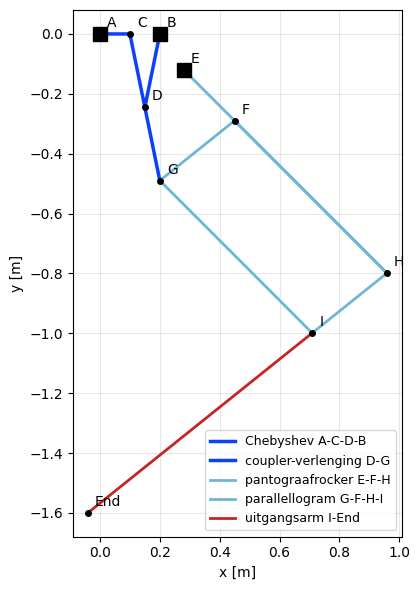

In [65]:
# Bron: cirkelsneden uit stangen_new.ipynb voor de beginschatting + plotpatroon uit
# Linkage_Project (3).ipynb (cel 12) voor het tekenen van het mechanisme.

# Stap 1: cirkelsneden voor theta1 = 0 -> haal alle hoeken eruit
theta1_0 = 0.0
pts_cs = solve_pose_circle(theta1_0)

phi_init_start = np.array([
    angle_of(pts_cs['D'] - B),              # theta2 (B -> D)
    angle_of(pts_cs['F'] - pts_cs['G']),    # theta3 (G -> F)
    angle_of(pts_cs['D'] - pts_cs['C']),    # theta4 (C -> D)
    angle_of(pts_cs['F'] - E),              # theta5 (E -> F)
    angle_of(pts_cs['I'] - pts_cs['G']),    # theta6 (G -> I)
    angle_of(pts_cs['I'] - pts_cs['H']),    # theta7 (H -> I)
])

# Stap 2: fsolve gebruikt de cirkelsneden-schatting -> moet ~direct convergeren
sol_0 = get_angles(theta1_0, phi_init_start, *geometry_parameters)
theta2_0, theta3_0, theta4_0, theta5_0, theta6_0, theta7_0 = sol_0

main_pts_0, ctrl_pts_0 = get_positions(theta1_0, *sol_0, *geometry_parameters)

print('Initiële hoeken (graden):')
for lab, val in zip(['theta2','theta3','theta4','theta5','theta6','theta7'], sol_0):
    print(f'  {lab} = {np.rad2deg(val):+7.2f}°')

res_0 = loop_closure_eqs(sol_0, theta1_0, *geometry_parameters)
print(f'\nResidu sluitingsvergelijkingen: ||F|| = {np.linalg.norm(res_0):.2e}')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')

A_p, B_p, C_p, D_p, E_p, F_p, G_p, H_p, I_p, End_p = main_pts_0

ax.plot([A_p[0], C_p[0], D_p[0], B_p[0]], [A_p[1], C_p[1], D_p[1], B_p[1]],
        '-', color='#0b40ff', lw=2.5, label='Chebyshev A-C-D-B')
ax.plot([D_p[0], G_p[0]], [D_p[1], G_p[1]], '-', color='#0b40ff', lw=2.5,
        label='coupler-verlenging D-G')
ax.plot([E_p[0], F_p[0], H_p[0]], [E_p[1], F_p[1], H_p[1]],
        '-', color='#6fb6d6', lw=2.0, label='pantograafrocker E-F-H')
ax.plot([G_p[0], F_p[0], H_p[0], I_p[0], G_p[0]],
        [G_p[1], F_p[1], H_p[1], I_p[1], G_p[1]],
        '-', color='#6fb6d6', lw=2.0, label='parallellogram G-F-H-I')
ax.plot([I_p[0], End_p[0]], [I_p[1], End_p[1]], '-', color='#c72525', lw=2.0,
        label='uitgangsarm I-End')

for fp, name in zip([A_p, B_p, E_p], ['A', 'B', 'E']):
    ax.plot(fp[0], fp[1], 'ks', ms=10, zorder=5)

names = ['A','B','C','D','E','F','G','H','I','End']
for name, pt in zip(names, main_pts_0):
    ax.plot(pt[0], pt[1], 'ko', ms=4, zorder=4)
    ax.annotate(name, pt, xytext=(5, 5), textcoords='offset points', fontsize=10)

ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()


### 5.2 Validatie: fsolve vs. cirkelsneden over volledige cyclus

De fsolve-methode en de cirkelsneden-methode moeten exact dezelfde posities geven. We laten $\theta_1$ een volledige omwenteling maken (van 0° tot 360°) en plotten het maximumverschil tussen beide methodes.


Maximum residu sluitingsvergelijkingen : 2.33e-11
Maximum verschil F   (fsolve vs cs)    : 4.22e-11 m
Maximum verschil End (fsolve vs cs)    : 1.66e-10 m


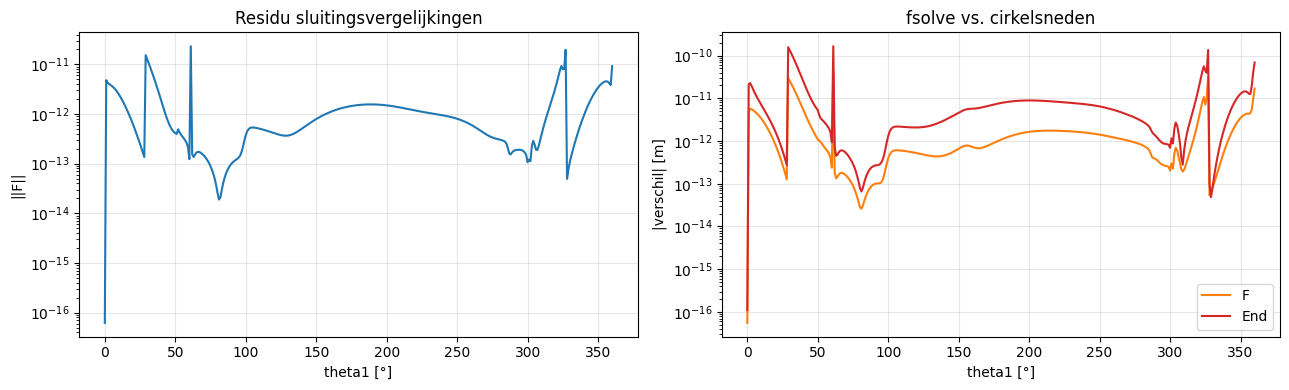

In [66]:
# Bron: cirkelsneden uit stangen_new.ipynb + sweep-patroon uit Linkage_Project (3).ipynb (cel 18).

n_check = 361
theta1_check = np.linspace(0.0, 2*np.pi, n_check)

diffs_F = np.zeros(n_check)
diffs_End = np.zeros(n_check)
residuals_check = np.zeros(n_check)

phi = phi_init_start.copy()
prev_F = pts_cs['F']

for k, th1 in enumerate(theta1_check):
    sol = get_angles(th1, phi, *geometry_parameters)
    main_pts, _ = get_positions(th1, *sol, *geometry_parameters)
    residuals_check[k] = np.linalg.norm(loop_closure_eqs(sol, th1, *geometry_parameters))

    pts = solve_pose_circle(th1, previous_F=prev_F)
    prev_F = pts['F']
    F_fs = main_pts[5];  End_fs = main_pts[9]
    diffs_F[k]   = np.linalg.norm(F_fs - pts['F'])
    diffs_End[k] = np.linalg.norm(End_fs - pts['End'])

    phi = sol  # warmstart volgende stap

print(f'Maximum residu sluitingsvergelijkingen : {residuals_check.max():.2e}')
print(f'Maximum verschil F   (fsolve vs cs)    : {diffs_F.max():.2e} m')
print(f'Maximum verschil End (fsolve vs cs)    : {diffs_End.max():.2e} m')

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].semilogy(np.rad2deg(theta1_check), np.maximum(residuals_check, 1e-18),
                color='tab:blue', lw=1.5)
axs[0].set_xlabel('theta1 [°]'); axs[0].set_ylabel('||F||')
axs[0].set_title('Residu sluitingsvergelijkingen')
axs[0].grid(True, alpha=0.3)

axs[1].semilogy(np.rad2deg(theta1_check), np.maximum(diffs_F, 1e-18),
                color='tab:orange', lw=1.5, label='F')
axs[1].semilogy(np.rad2deg(theta1_check), np.maximum(diffs_End, 1e-18),
                color='tab:red', lw=1.5, label='End')
axs[1].set_xlabel('theta1 [°]'); axs[1].set_ylabel('|verschil| [m]')
axs[1].set_title('fsolve vs. cirkelsneden')
axs[1].legend(); axs[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Snelheidsanalyse

Tijd-afgeleide van de sluitingsvergelijkingen geeft:

$$\sum_i \frac{\partial \vec F}{\partial \theta_i}\,\dot\theta_i = 0$$

We scheiden de bekende ($\dot\theta_1$) van de onbekende termen:

$$\boxed{\;A(\theta)\,\dot{\boldsymbol\theta}_u = b_v(\theta,\,\dot\theta_1)\;}$$

waarbij $A$ de $6\times 6$ Jacobiaan is van $\vec F$ naar $[\theta_2,\theta_3,\theta_4,\theta_5,\theta_6,\theta_7]$, en $b_v = -\partial \vec F/\partial\theta_1\cdot\dot\theta_1$.

Concreet (zie afleiding sluitingsvergelijkingen):

$$A = \begin{pmatrix}
r_2\sin\theta_2 & 0 & -\ell_{41}\sin\theta_4 & 0 & 0 & 0 \\
-r_2\cos\theta_2 & 0 & \ell_{41}\cos\theta_4 & 0 & 0 & 0 \\
0 & -r_3\sin\theta_3 & -(\ell_{41}+\ell_{42})\sin\theta_4 & \ell_{51}\sin\theta_5 & 0 & 0 \\
0 & r_3\cos\theta_3 & (\ell_{41}+\ell_{42})\cos\theta_4 & -\ell_{51}\cos\theta_5 & 0 & 0 \\
0 & -r_3\sin\theta_3 & 0 & -\ell_{52}\sin\theta_5 & r_6\sin\theta_6 & -\ell_{71}\sin\theta_7 \\
0 & r_3\cos\theta_3 & 0 & \ell_{52}\cos\theta_5 & -r_6\cos\theta_6 & \ell_{71}\cos\theta_7
\end{pmatrix}$$

$$b_v = \begin{pmatrix}
r_1\sin\theta_1\\
-r_1\cos\theta_1\\
r_1\sin\theta_1\\
-r_1\cos\theta_1\\
0\\
0
\end{pmatrix} \dot\theta_1$$


In [67]:
# Bron: patroon uit Linkage_Project (3).ipynb, cel 14 (get_angular_velocity).
# Coefficienten herafgeleid voor onze sluitingsvergelijkingen.

def get_angular_velocity(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                         dtheta1,
                         r1, r2, r3, r6, l41, l42, l51, l52, l71, r7):
    '''Los A * dtheta_u = b_v op. Returns [dtheta2..dtheta7].'''
    A_mat = np.array([
        # rij F1: ∂F1/∂(theta2,3,4,5,6,7)
        [ r2*np.sin(theta2), 0.0, -l41*np.sin(theta4), 0.0, 0.0, 0.0],
        # rij F2
        [-r2*np.cos(theta2), 0.0,  l41*np.cos(theta4), 0.0, 0.0, 0.0],
        # rij F3
        [0.0, -r3*np.sin(theta3), -(l41+l42)*np.sin(theta4),  l51*np.sin(theta5), 0.0, 0.0],
        # rij F4
        [0.0,  r3*np.cos(theta3),  (l41+l42)*np.cos(theta4), -l51*np.cos(theta5), 0.0, 0.0],
        # rij F5
        [0.0, -r3*np.sin(theta3), 0.0, -l52*np.sin(theta5),  r6*np.sin(theta6), -l71*np.sin(theta7)],
        # rij F6
        [0.0,  r3*np.cos(theta3), 0.0,  l52*np.cos(theta5), -r6*np.cos(theta6),  l71*np.cos(theta7)],
    ])

    # b_v = -∂F/∂theta1 * dtheta1
    b_v = np.array([
         r1*np.sin(theta1)*dtheta1,   # -∂F1/∂theta1 = +r1*sin(theta1)
        -r1*np.cos(theta1)*dtheta1,   # -∂F2/∂theta1 = -r1*cos(theta1)
         r1*np.sin(theta1)*dtheta1,
        -r1*np.cos(theta1)*dtheta1,
         0.0,
         0.0,
    ])

    return np.linalg.solve(A_mat, b_v)


def get_linear_velocity(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                        dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                        r1, r2, r3, r6, l41, l42, l51, l52, l71, r7):
    '''Bereken lineaire snelheden van A..End via twee routes (main + control).

    Patroon van Linkage_Project (3).ipynb cel 14: voor elk segment is
    v_eind = v_begin + omega x r, met omega = [0,0,dtheta] en r = [Lcos, Lsin, 0].'''
    def w(dth):
        return np.array([0.0, 0.0, dth])
    def r3d(vec2):
        return np.array([vec2[0], vec2[1], 0.0])

    v_A = np.zeros(3)
    v_B = np.zeros(3)
    v_E = np.zeros(3)
    # Hoofdroute
    v_C = v_A + np.cross(w(dtheta1), r3d(rotate_vector([r1, 0], theta1)))
    v_D = v_B + np.cross(w(dtheta2), r3d(rotate_vector([r2, 0], theta2)))
    v_G = v_A + np.cross(w(dtheta1), r3d(rotate_vector([r1, 0], theta1))) \
              + np.cross(w(dtheta4), r3d(rotate_vector([l41+l42, 0], theta4)))
    v_F = v_G + np.cross(w(dtheta3), r3d(rotate_vector([r3, 0], theta3)))
    v_H = v_F + np.cross(w(dtheta5), r3d(rotate_vector([l52, 0], theta5)))
    v_I = v_G + np.cross(w(dtheta6), r3d(rotate_vector([r6, 0], theta6)))
    v_End = v_I + np.cross(w(dtheta7), r3d(rotate_vector([r7, 0], theta7)))
    # Controleroute (uit E)
    v_F_ctrl = v_E + np.cross(w(dtheta5), r3d(rotate_vector([l51, 0], theta5)))
    v_H_ctrl = v_E + np.cross(w(dtheta5), r3d(rotate_vector([l51+l52, 0], theta5)))
    v_I_ctrl = v_H_ctrl + np.cross(w(dtheta7), r3d(rotate_vector([l71, 0], theta7)))
    v_End_ctrl = v_I_ctrl + np.cross(w(dtheta7), r3d(rotate_vector([r7, 0], theta7)))

    main    = np.array([v[:2] for v in (v_A, v_B, v_C, v_D, v_E, v_F,      v_G, v_H,      v_I,      v_End)])
    control = np.array([v[:2] for v in (v_A, v_B, v_C, v_D, v_E, v_F_ctrl, v_G, v_H_ctrl, v_I_ctrl, v_End_ctrl)])
    return main, control


## 7. Versnellingsanalyse

Tweede tijd-afgeleide van de sluitingsvergelijkingen:

$$\sum_i \frac{\partial \vec F}{\partial \theta_i}\ddot\theta_i + \sum_i \frac{\partial^2 \vec F}{\partial \theta_i^2}\,\dot\theta_i^2 = 0$$

(De gemengde tweede afgeleiden zijn nul omdat $F$ een som van enkelvariabele cos/sin-termen is.)

Dat geeft:

$$\boxed{\;A(\theta)\,\ddot{\boldsymbol\theta}_u = b_a(\theta,\dot\theta,\ddot\theta_1)\;}$$

met dezelfde $A$ als bij de snelheid, en

$$b_a = -\frac{\partial \vec F}{\partial\theta_1}\ddot\theta_1 - \sum_{i=1}^7 \frac{\partial^2 \vec F}{\partial\theta_i^2}\dot\theta_i^2$$

Concreet bevat $b_a$ termen als $r_1\cos\theta_1\dot\theta_1^2$ (centripetaal-bijdrage van de bekende invoer), $-r_2\cos\theta_2\dot\theta_2^2$ enz.


In [68]:
# Bron: patroon uit Linkage_Project (3).ipynb, cel 16 (get_angular_acceleration).
# Coefficienten herafgeleid voor onze sluitingsvergelijkingen.

def get_angular_acceleration(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                             dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                             ddtheta1,
                             r1, r2, r3, r6, l41, l42, l51, l52, l71, r7):
    '''Los A * ddtheta_u = b_a op. Returns [ddtheta2..ddtheta7].'''
    # Zelfde A als bij snelheid
    A_mat = np.array([
        [ r2*np.sin(theta2), 0.0, -l41*np.sin(theta4), 0.0, 0.0, 0.0],
        [-r2*np.cos(theta2), 0.0,  l41*np.cos(theta4), 0.0, 0.0, 0.0],
        [0.0, -r3*np.sin(theta3), -(l41+l42)*np.sin(theta4),  l51*np.sin(theta5), 0.0, 0.0],
        [0.0,  r3*np.cos(theta3),  (l41+l42)*np.cos(theta4), -l51*np.cos(theta5), 0.0, 0.0],
        [0.0, -r3*np.sin(theta3), 0.0, -l52*np.sin(theta5),  r6*np.sin(theta6), -l71*np.sin(theta7)],
        [0.0,  r3*np.cos(theta3), 0.0,  l52*np.cos(theta5), -r6*np.cos(theta6),  l71*np.cos(theta7)],
    ])

    # b_a opbouw: -∂F/∂theta1 * ddtheta1 - sum_i ∂^2 F/∂theta_i^2 * dtheta_i^2
    # Tweede afgeleiden:
    #   F = ... + c*cos(theta_j) ...  ->  ∂^2/∂theta_j^2 = -c*cos(theta_j)
    #   F = ... + c*sin(theta_j) ...  ->  ∂^2/∂theta_j^2 = -c*sin(theta_j)
    b_a = np.array([
        # F1: r1*cos(th1) + l41*cos(th4) - r2*cos(th2) - x_B
        r1*np.sin(theta1)*ddtheta1
        + r1*np.cos(theta1)*dtheta1**2
        - r2*np.cos(theta2)*dtheta2**2
        + l41*np.cos(theta4)*dtheta4**2,
        # F2: r1*sin(th1) + l41*sin(th4) - r2*sin(th2) - y_B
        -r1*np.cos(theta1)*ddtheta1
        + r1*np.sin(theta1)*dtheta1**2
        - r2*np.sin(theta2)*dtheta2**2
        + l41*np.sin(theta4)*dtheta4**2,
        # F3: r1*cos(th1) + (l41+l42)*cos(th4) + r3*cos(th3) - l51*cos(th5) - x_E
        r1*np.sin(theta1)*ddtheta1
        + r1*np.cos(theta1)*dtheta1**2
        + (l41+l42)*np.cos(theta4)*dtheta4**2
        + r3*np.cos(theta3)*dtheta3**2
        - l51*np.cos(theta5)*dtheta5**2,
        # F4
        -r1*np.cos(theta1)*ddtheta1
        + r1*np.sin(theta1)*dtheta1**2
        + (l41+l42)*np.sin(theta4)*dtheta4**2
        + r3*np.sin(theta3)*dtheta3**2
        - l51*np.sin(theta5)*dtheta5**2,
        # F5: r3*cos(th3) + l52*cos(th5) + l71*cos(th7) - r6*cos(th6)
         r3*np.cos(theta3)*dtheta3**2
        + l52*np.cos(theta5)*dtheta5**2
        + l71*np.cos(theta7)*dtheta7**2
        - r6*np.cos(theta6)*dtheta6**2,
        # F6
         r3*np.sin(theta3)*dtheta3**2
        + l52*np.sin(theta5)*dtheta5**2
        + l71*np.sin(theta7)*dtheta7**2
        - r6*np.sin(theta6)*dtheta6**2,
    ])

    return np.linalg.solve(A_mat, b_a)


def get_linear_acceleration(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                            dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                            ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
                            r1, r2, r3, r6, l41, l42, l51, l52, l71, r7):
    '''Lineaire versnelling: a = alpha x r + omega x (omega x r). Linkage_Project-patroon.'''
    def w(dth): return np.array([0.0, 0.0, dth])
    def al(ddth): return np.array([0.0, 0.0, ddth])
    def r3d(v2): return np.array([v2[0], v2[1], 0.0])

    def link_acc(a_prev, dth, ddth, L, theta):
        r_vec = r3d(rotate_vector([L, 0], theta))
        return a_prev + np.cross(al(ddth), r_vec) + np.cross(w(dth), np.cross(w(dth), r_vec))

    a_A = np.zeros(3); a_B = np.zeros(3); a_E = np.zeros(3)
    a_C = link_acc(a_A, dtheta1, ddtheta1, r1, theta1)
    a_D = link_acc(a_B, dtheta2, ddtheta2, r2, theta2)
    a_G = link_acc(link_acc(a_A, dtheta1, ddtheta1, r1, theta1),
                   dtheta4, ddtheta4, l41+l42, theta4)
    a_F = link_acc(a_G, dtheta3, ddtheta3, r3, theta3)
    a_H = link_acc(a_F, dtheta5, ddtheta5, l52, theta5)
    a_I = link_acc(a_G, dtheta6, ddtheta6, r6, theta6)
    a_End = link_acc(a_I, dtheta7, ddtheta7, r7, theta7)

    a_F_c = link_acc(a_E, dtheta5, ddtheta5, l51, theta5)
    a_H_c = link_acc(a_E, dtheta5, ddtheta5, l51+l52, theta5)
    a_I_c = link_acc(a_H_c, dtheta7, ddtheta7, l71, theta7)
    a_End_c = link_acc(a_I_c, dtheta7, ddtheta7, r7, theta7)

    main    = np.array([a[:2] for a in (a_A, a_B, a_C, a_D, a_E, a_F,   a_G, a_H,   a_I,   a_End)])
    control = np.array([a[:2] for a in (a_A, a_B, a_C, a_D, a_E, a_F_c, a_G, a_H_c, a_I_c, a_End_c)])
    return main, control


## 8. Volledige simulatie over één cyclus

We laten $\theta_1$ in $T = 5$ s een volledige omwenteling (360°) maken bij **constante hoeksnelheid**. Dat is een natuurlijke aandrijving voor een Chebyshev-walker: de motor levert constante toeren.

Voor elk tijdstip lossen we sequentieel op:

1. Hoeken via `fsolve` (warmstart met vorige oplossing).
2. Posities via `get_positions` (twee routes voor kruiscontrole).
3. Hoeksnelheden via `get_angular_velocity` (1 lineair stelsel).
4. Hoekversnellingen via `get_angular_acceleration` (zelfde A-matrix).
5. Lineaire snelheden/versnellingen via `get_linear_velocity/acceleration`.


In [69]:
# Bron: looppatroon uit Linkage_Project (3).ipynb, cel 18 (mainloop).
# Aangepast voor 6 onbekenden + onze parameterbundel.

# Tijdvector
T_cycle = 5.0           # s, een volledige omwenteling
omega1 = 2.0*np.pi / T_cycle    # rad/s, constant
Ts = 0.01               # s
t = np.arange(0.0, T_cycle + Ts/2, Ts)
n_t = len(t)

# Aandrijving
theta1_arr  = omega1 * t
dtheta1_arr = omega1 * np.ones_like(t)
ddtheta1_arr = np.zeros_like(t)

# Arrays voor resultaten
angles      = np.zeros((n_t, 6))  # [theta2..theta7]
dangles     = np.zeros((n_t, 6))
ddangles    = np.zeros((n_t, 6))
positions   = np.zeros((n_t, 10, 2))  # 10 punten: A,B,C,D,E,F,G,H,I,End
positions_c = np.zeros((n_t, 10, 2))
velocities  = np.zeros((n_t, 10, 2))
velocities_c = np.zeros((n_t, 10, 2))
accelerations = np.zeros((n_t, 10, 2))
accelerations_c = np.zeros((n_t, 10, 2))

# Warmstart: cirkelsneden voor theta1=0
pts_init = solve_pose_circle(theta1_arr[0])
phi_warm = np.array([
    angle_of(pts_init['D'] - B),
    angle_of(pts_init['F'] - pts_init['G']),
    angle_of(pts_init['D'] - pts_init['C']),
    angle_of(pts_init['F'] - E),
    angle_of(pts_init['I'] - pts_init['G']),
    angle_of(pts_init['I'] - pts_init['H']),
])

for k in range(n_t):
    th1 = theta1_arr[k]
    sol = get_angles(th1, phi_warm, *geometry_parameters)
    angles[k] = sol
    th2, th3, th4, th5, th6, th7 = sol

    main_pts, ctrl_pts = get_positions(th1, *sol, *geometry_parameters)
    positions[k] = main_pts
    positions_c[k] = ctrl_pts

    dsol = get_angular_velocity(th1, *sol, dtheta1_arr[k], *link_parameters)
    dangles[k] = dsol
    dth2, dth3, dth4, dth5, dth6, dth7 = dsol

    ddsol = get_angular_acceleration(th1, *sol, dtheta1_arr[k], *dsol, ddtheta1_arr[k],
                                     *link_parameters)
    ddangles[k] = ddsol

    v_main, v_ctrl = get_linear_velocity(th1, *sol, dtheta1_arr[k], *dsol, *link_parameters)
    velocities[k] = v_main
    velocities_c[k] = v_ctrl

    a_main, a_ctrl = get_linear_acceleration(th1, *sol, dtheta1_arr[k], *dsol,
                                              ddtheta1_arr[k], *ddsol, *link_parameters)
    accelerations[k] = a_main
    accelerations_c[k] = a_ctrl

    phi_warm = sol  # voor volgende iteratie

# Verkort hoeken voor leesbaarheid
theta2_arr = angles[:, 0];   theta3_arr = angles[:, 1]
theta4_arr = angles[:, 2];   theta5_arr = angles[:, 3]
theta6_arr = angles[:, 4];   theta7_arr = angles[:, 5]
dtheta2_arr = dangles[:, 0]; dtheta3_arr = dangles[:, 1]
dtheta4_arr = dangles[:, 2]; dtheta5_arr = dangles[:, 3]
dtheta6_arr = dangles[:, 4]; dtheta7_arr = dangles[:, 5]
ddtheta2_arr = ddangles[:, 0]; ddtheta3_arr = ddangles[:, 1]
ddtheta4_arr = ddangles[:, 2]; ddtheta5_arr = ddangles[:, 3]
ddtheta6_arr = ddangles[:, 4]; ddtheta7_arr = ddangles[:, 5]

# Verkort punten
NAME_TO_IDX = {'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6,'H':7,'I':8,'End':9}
def P(name): return positions[:, NAME_TO_IDX[name], :]
def V(name): return velocities[:, NAME_TO_IDX[name], :]
def Acc(name): return accelerations[:, NAME_TO_IDX[name], :]

print(f'Simulatie klaar: {n_t} tijdstappen, T_cycle = {T_cycle} s, omega1 = {omega1:.3f} rad/s')
print(f'Versterking (E-End / E-G) = {versterking:.3f}')
print(f'End range: x in [{P("End")[:,0].min():.4f}, {P("End")[:,0].max():.4f}] m')
print(f'             y in [{P("End")[:,1].min():.4f}, {P("End")[:,1].max():.4f}] m')


Simulatie klaar: 501 tijdstappen, T_cycle = 5.0 s, omega1 = 1.257 rad/s
Versterking (E-End / E-G) = 4.000
End range: x in [-0.9807, 0.9007] m
             y in [-1.5996, -1.2400] m


## 9. Resultaten

### 9.1 Hoeken, hoeksnelheden en hoekversnellingen


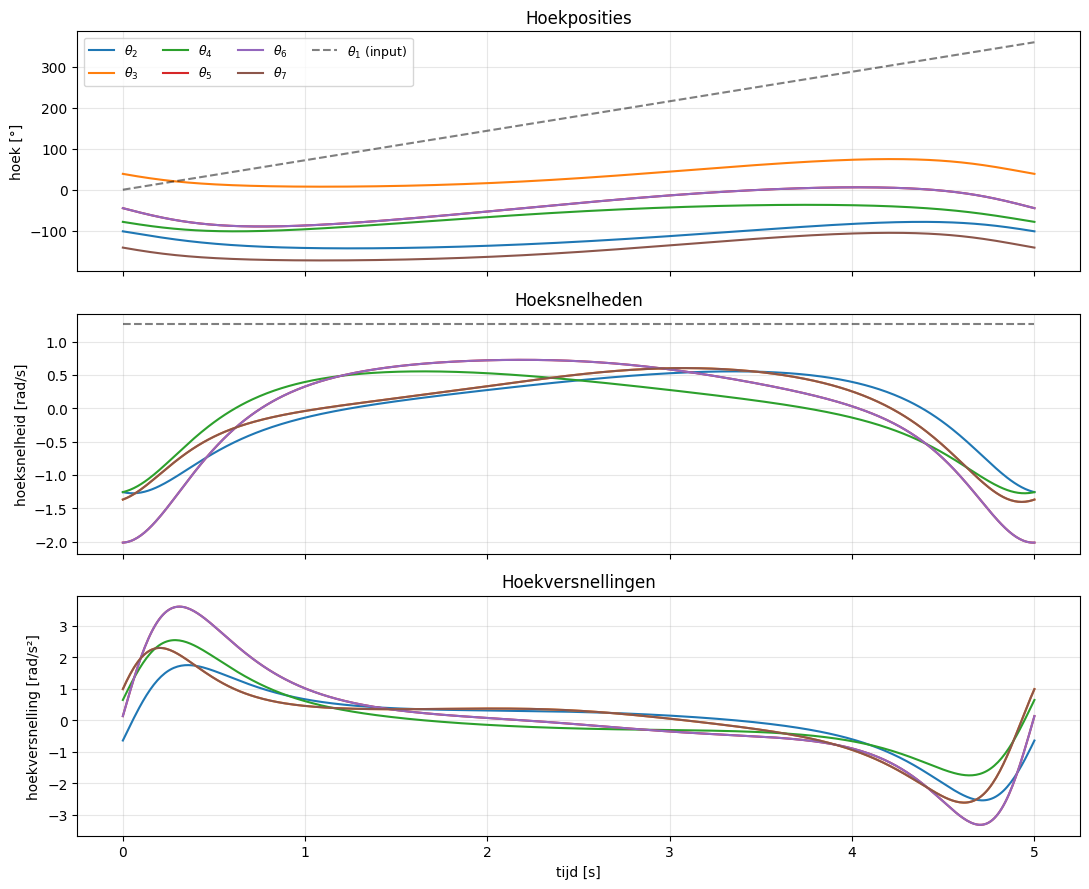

In [70]:
# Bron: plotpatroon uit Linkage_Project (3).ipynb, cellen 22, 24, 30.

fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

labels = [r'$\theta_2$', r'$\theta_3$', r'$\theta_4$', r'$\theta_5$', r'$\theta_6$', r'$\theta_7$']

for j in range(6):
    axs[0].plot(t, np.rad2deg(angles[:, j]), label=labels[j])
axs[0].plot(t, np.rad2deg(theta1_arr), '--', color='black', alpha=0.5, label=r'$\theta_1$ (input)')
axs[0].set_ylabel('hoek [°]'); axs[0].legend(ncol=4, fontsize=9); axs[0].grid(True, alpha=0.3)
axs[0].set_title('Hoekposities')

for j in range(6):
    axs[1].plot(t, dangles[:, j], label=labels[j])
axs[1].plot(t, dtheta1_arr, '--', color='black', alpha=0.5)
axs[1].set_ylabel('hoeksnelheid [rad/s]'); axs[1].grid(True, alpha=0.3)
axs[1].set_title('Hoeksnelheden')

for j in range(6):
    axs[2].plot(t, ddangles[:, j], label=labels[j])
axs[2].set_ylabel('hoekversnelling [rad/s²]')
axs[2].set_xlabel('tijd [s]'); axs[2].grid(True, alpha=0.3)
axs[2].set_title('Hoekversnellingen')

plt.tight_layout(); plt.show()


### 9.2 Lineaire snelheid en versnelling van $End$

De **analytische** snelheid/versnelling van het eindpunt komt uit `get_linear_velocity/acceleration`. Als controle berekenen we ook de **numerieke** afgeleide van de $End$-positie (`np.gradient`). De twee moeten op machineprecisie overeenkomen.


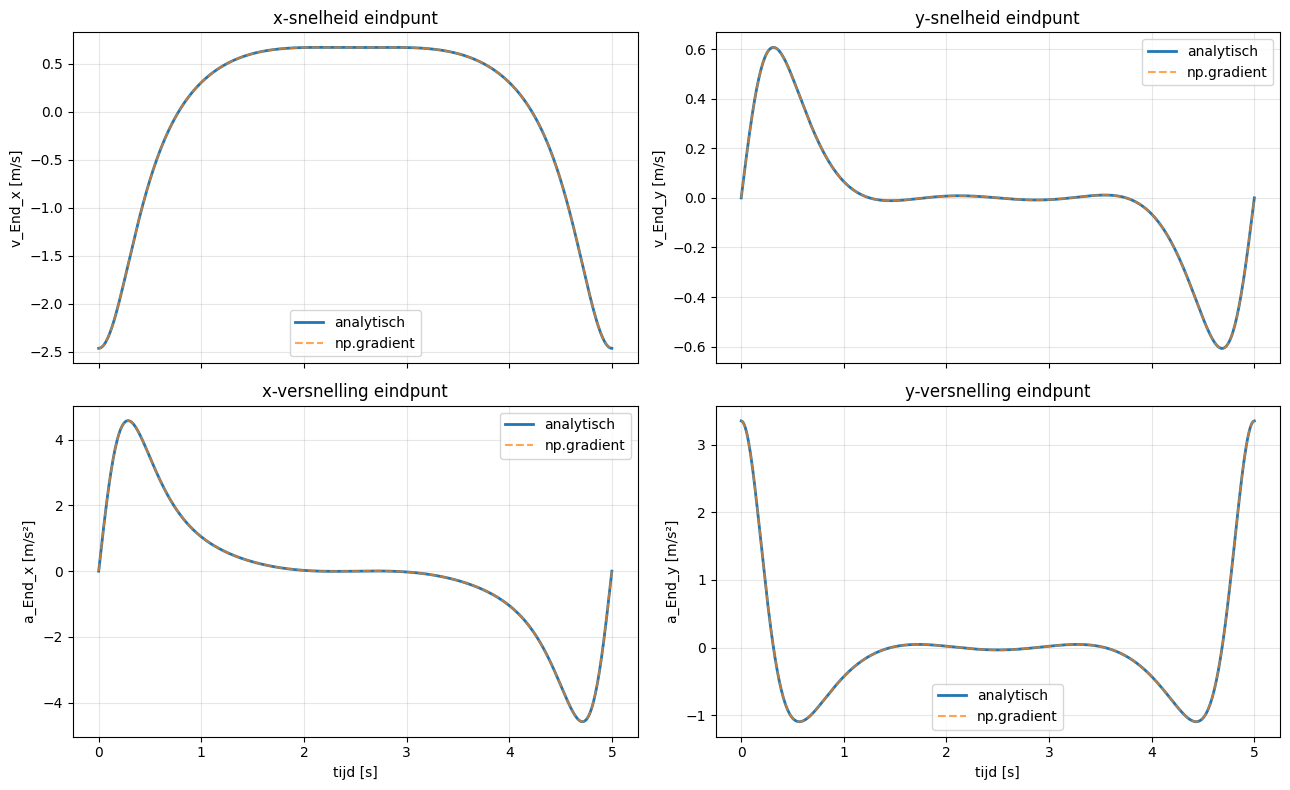

Max fout |v_analytisch - v_numeriek|: 9.39e-04 m/s
Max fout |a_analytisch - a_numeriek|: 4.16e-03 m/s²
(np.gradient is van eindige orde, dus een fout ~Ts² is normaal.)


In [71]:
# Bron: kruiscontrole-patroon uit Linkage_Project (3).ipynb, cellen 28 + 34.

end_pos = P('End')
end_vel = V('End')
end_acc = Acc('End')

# Numerieke afgeleide ter controle
end_vel_num = np.gradient(end_pos, t, axis=0, edge_order=2)
end_acc_num = np.gradient(end_vel, t, axis=0, edge_order=2)

fig, axs = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

axs[0,0].plot(t, end_vel[:,0], label='analytisch', lw=2)
axs[0,0].plot(t, end_vel_num[:,0], '--', label='np.gradient', alpha=0.7)
axs[0,0].set_ylabel('v_End_x [m/s]'); axs[0,0].grid(True, alpha=0.3); axs[0,0].legend()
axs[0,0].set_title('x-snelheid eindpunt')

axs[0,1].plot(t, end_vel[:,1], lw=2, label='analytisch')
axs[0,1].plot(t, end_vel_num[:,1], '--', alpha=0.7, label='np.gradient')
axs[0,1].set_ylabel('v_End_y [m/s]'); axs[0,1].grid(True, alpha=0.3); axs[0,1].legend()
axs[0,1].set_title('y-snelheid eindpunt')

axs[1,0].plot(t, end_acc[:,0], lw=2, label='analytisch')
axs[1,0].plot(t, end_acc_num[:,0], '--', alpha=0.7, label='np.gradient')
axs[1,0].set_xlabel('tijd [s]'); axs[1,0].set_ylabel('a_End_x [m/s²]')
axs[1,0].grid(True, alpha=0.3); axs[1,0].legend()
axs[1,0].set_title('x-versnelling eindpunt')

axs[1,1].plot(t, end_acc[:,1], lw=2, label='analytisch')
axs[1,1].plot(t, end_acc_num[:,1], '--', alpha=0.7, label='np.gradient')
axs[1,1].set_xlabel('tijd [s]'); axs[1,1].set_ylabel('a_End_y [m/s²]')
axs[1,1].grid(True, alpha=0.3); axs[1,1].legend()
axs[1,1].set_title('y-versnelling eindpunt')

plt.tight_layout(); plt.show()

err_v = np.linalg.norm(end_vel - end_vel_num, axis=1)
err_a = np.linalg.norm(end_acc - end_acc_num, axis=1)
print(f'Max fout |v_analytisch - v_numeriek|: {err_v.max():.2e} m/s')
print(f'Max fout |a_analytisch - a_numeriek|: {err_a.max():.2e} m/s²')
print('(np.gradient is van eindige orde, dus een fout ~Ts² is normaal.)')


## 10. Trajecten van $G$ en $End$

$G$ is het *koppelpunt* tussen de Chebyshev-vierstang en de pantograaf — zijn baan is de klassieke Chebyshev-rocker-kruk-curve. $End$ is een **viervoudig vergroting** daarvan (door de pantograafwet), zoals duidelijk wordt in deze grafiek.


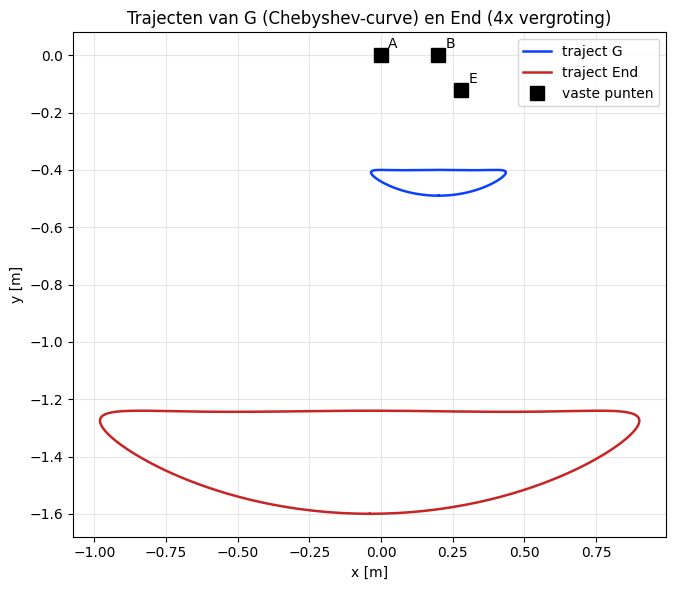

Slag (peak-to-peak) van End:
  x-slag = 1.8814 m
  y-slag = 0.3596 m
Slag van G:
  x-slag = 0.4704 m
  y-slag = 0.0899 m

Verhouding (End-slag / G-slag) ~ versterkingsfactor:
  x: 4.000
  y: 4.000


In [72]:
# Bron: trajectplot uit bestaand 01-notebook (cel 29 van de backup) + stangen_new.ipynb.

G_path = P('G')
End_path = P('End')

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(G_path[:, 0], G_path[:, 1], color='#0b40ff', lw=1.8, label='traject G')
ax.plot(End_path[:, 0], End_path[:, 1], color='#c72525', lw=1.8, label='traject End')
ax.plot([x_A, x_B, x_E], [y_A, y_B, y_E], 'ks', ms=10, label='vaste punten')
for nm, x, y in [('A',x_A,y_A), ('B',x_B,y_B), ('E',x_E,y_E)]:
    ax.annotate(nm, (x,y), xytext=(5,5), textcoords='offset points')

ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_title('Trajecten van G (Chebyshev-curve) en End (4x vergroting)')
ax.legend(loc='best')
plt.tight_layout(); plt.show()

# Trajectmaten
def stroke(arr, axis):
    return arr[:, axis].max() - arr[:, axis].min()

print('Slag (peak-to-peak) van End:')
print(f'  x-slag = {stroke(End_path, 0):.4f} m')
print(f'  y-slag = {stroke(End_path, 1):.4f} m')
print('Slag van G:')
print(f'  x-slag = {stroke(G_path, 0):.4f} m')
print(f'  y-slag = {stroke(G_path, 1):.4f} m')
print(f'\nVerhouding (End-slag / G-slag) ~ versterkingsfactor:')
print(f'  x: {stroke(End_path,0)/stroke(G_path,0):.3f}')
print(f'  y: {stroke(End_path,1)/stroke(G_path,1):.3f}')


## 11. Animatie

Animatie van het volledige mechanisme over één cyclus. De gestippelde lijnen tonen de banen van $G$ en $End$.


In [ ]:
# Bron: animatiepatroon uit Linkage_Project (3).ipynb, cel 20, vereenvoudigd voor onze topologie.

fig, ax = plt.subplots(figsize=(9, 7))
all_pts = positions.reshape(-1, 2)
pad = 0.05
ax.set_xlim(all_pts[:,0].min()-pad, all_pts[:,0].max()+pad)
ax.set_ylim(all_pts[:,1].min()-pad, all_pts[:,1].max()+pad)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')

# Statische trajecten
ax.plot(G_path[:,0], G_path[:,1], '--', color='#0b40ff', alpha=0.4, lw=1.0)
ax.plot(End_path[:,0], End_path[:,1], '--', color='#c72525', alpha=0.4, lw=1.0)

cheb_line, = ax.plot([], [], '-o', color='#0b40ff', lw=2.5, ms=5)
dg_line,   = ax.plot([], [], '-',  color='#0b40ff', lw=2.5)
panto_line, = ax.plot([], [], '-o', color='#6fb6d6', lw=2.0, ms=5)
out_line, = ax.plot([], [], '-o', color='#c72525', lw=2.0, ms=5)
para_line, = ax.plot([], [], '-', color='#6fb6d6', lw=2.0)
fixed_pts, = ax.plot([x_A,x_B,x_E], [y_A,y_B,y_E], 'ks', ms=10)
title = ax.set_title('')

def draw(k):
    pts = positions[k]
    A_,B_,C_,D_,E_,F_,G_,H_,I_,End_ = pts
    cheb_line.set_data([A_[0],C_[0],D_[0],B_[0]], [A_[1],C_[1],D_[1],B_[1]])
    dg_line.set_data([D_[0],G_[0]], [D_[1],G_[1]])
    panto_line.set_data([E_[0],F_[0],H_[0]], [E_[1],F_[1],H_[1]])
    para_line.set_data([G_[0],F_[0],H_[0],I_[0],G_[0]], [G_[1],F_[1],H_[1],I_[1],G_[1]])
    out_line.set_data([I_[0],End_[0]], [I_[1],End_[1]])
    title.set_text(f'theta1 = {np.rad2deg(theta1_arr[k]):.0f}°,  t = {t[k]:.2f} s')
    return cheb_line, dg_line, panto_line, para_line, out_line, title

frame_ids = np.arange(0, n_t, max(1, n_t//120))   # ~120 frames
ani = animation.FuncAnimation(fig, draw, frames=frame_ids, interval=50, blit=False)
plt.close(fig)
HTML(ani.to_jshtml())


## 12. Numerieke controles

Drie onafhankelijke controles op de oplossing:

1. **Lengteconstante:** elke stang moet dezelfde lengte hebben over de hele cyclus.
2. **Parallelogram-sluiting:** $|GF|-|HI|$ en $|FH|-|GI|$ moeten 0 zijn, en de zijden moeten parallel zijn.
3. **Route-consistentie:** posities/snelheden via de hoofdroute (uit $A$, $B$) en via de controleroute (uit $E$) moeten gelijk zijn.


In [74]:
# Bron: validatie-patroon uit stangen_new.ipynb (cel 686ace05).

def dist_series(name_p, name_q):
    return np.linalg.norm(positions[:, NAME_TO_IDX[name_q]] - positions[:, NAME_TO_IDX[name_p]], axis=1)

length_checks = {
    'AB':  (dist_series('A','B'), d1),
    'AC':  (dist_series('A','C'), r1),
    'BD':  (dist_series('B','D'), r2),
    'CD':  (dist_series('C','D'), l41),
    'DG':  (dist_series('D','G'), l42),
    'EF':  (dist_series('E','F'), l51),
    'FH':  (dist_series('F','H'), l52),
    'GF':  (dist_series('G','F'), r3),
    'GI':  (dist_series('G','I'), r6),
    'HI':  (dist_series('H','I'), l71),
    'IEnd':(dist_series('I','End'), r7),
}

print('1) Lengtefouten over volledige cyclus:')
max_len_err = 0.0
for name, (vals, nominal) in length_checks.items():
    err = np.max(np.abs(vals - nominal))
    max_len_err = max(max_len_err, err)
    print(f'   |{name}| nominaal = {nominal:.4f} m,  max fout = {err:.2e} m')

print(f'\n   -> globaal maximum: {max_len_err:.2e} m')

# Parallelogram sluiting
GF_v = positions[:,NAME_TO_IDX['F']] - positions[:,NAME_TO_IDX['G']]
HI_v = positions[:,NAME_TO_IDX['I']] - positions[:,NAME_TO_IDX['H']]
FH_v = positions[:,NAME_TO_IDX['H']] - positions[:,NAME_TO_IDX['F']]
GI_v = positions[:,NAME_TO_IDX['I']] - positions[:,NAME_TO_IDX['G']]

def cross2(a, b):
    return a[:,0]*b[:,1] - a[:,1]*b[:,0]

print('\n2) Parallelogramcontrole G-F-H-I:')
print(f'   max ||GF|-|HI||                = {np.max(np.abs(np.linalg.norm(GF_v,1) - np.linalg.norm(HI_v,1))):.2e}')
print(f'   max ||FH|-|GI||                = {np.max(np.abs(np.linalg.norm(FH_v,1) - np.linalg.norm(GI_v,1))):.2e}')
print(f'   max kruisproduct GF x (-HI)    = {np.max(np.abs(cross2(GF_v, -HI_v))):.2e}')
print(f'   max kruisproduct FH x GI       = {np.max(np.abs(cross2(FH_v, GI_v))):.2e}')

# Route-consistentie
pos_diff = np.linalg.norm(positions - positions_c, axis=2).max()
vel_diff = np.linalg.norm(velocities - velocities_c, axis=2).max()
acc_diff = np.linalg.norm(accelerations - accelerations_c, axis=2).max()
print('\n3) Route-consistentie (main vs control):')
print(f'   max positie-verschil    = {pos_diff:.2e} m')
print(f'   max snelheid-verschil   = {vel_diff:.2e} m/s')
print(f'   max versnelling-verschil= {acc_diff:.2e} m/s²')


1) Lengtefouten over volledige cyclus:
   |AB| nominaal = 0.2000 m,  max fout = 0.00e+00 m
   |AC| nominaal = 0.1000 m,  max fout = 1.39e-17 m
   |BD| nominaal = 0.2500 m,  max fout = 2.78e-17 m
   |CD| nominaal = 0.2500 m,  max fout = 1.06e-11 m
   |DG| nominaal = 0.2500 m,  max fout = 1.06e-11 m
   |EF| nominaal = 0.2400 m,  max fout = 1.22e-11 m
   |FH| nominaal = 0.7200 m,  max fout = 2.22e-16 m
   |GF| nominaal = 0.3200 m,  max fout = 1.11e-16 m
   |GI| nominaal = 0.7200 m,  max fout = 2.22e-16 m
   |HI| nominaal = 0.3200 m,  max fout = 1.11e-15 m
   |IEnd| nominaal = 0.9600 m,  max fout = 2.22e-16 m

   -> globaal maximum: 1.22e-11 m

2) Parallelogramcontrole G-F-H-I:
   max ||GF|-|HI||                = 0.00e+00
   max ||FH|-|GI||                = 5.68e-14
   max kruisproduct GF x (-HI)    = 1.04e-16
   max kruisproduct FH x GI       = 7.77e-16

3) Route-consistentie (main vs control):
   max positie-verschil    = 1.30e-11 m
   max snelheid-verschil   = 4.97e-16 m/s
   max versne

## 13. Singulariteiten en kritische configuraties

De Jacobiaan $A(\theta)$ wordt **singulier** wanneer twee of meer stangen collineair worden — daar verliest het mechanisme momentaan een graad van controle. We meten dat met het **conditiegetal** $\kappa(A)$: hoe groter, hoe slechter geconditioneerd. Een piek in $\kappa$ wijst op een (bijna)-singulariteit.


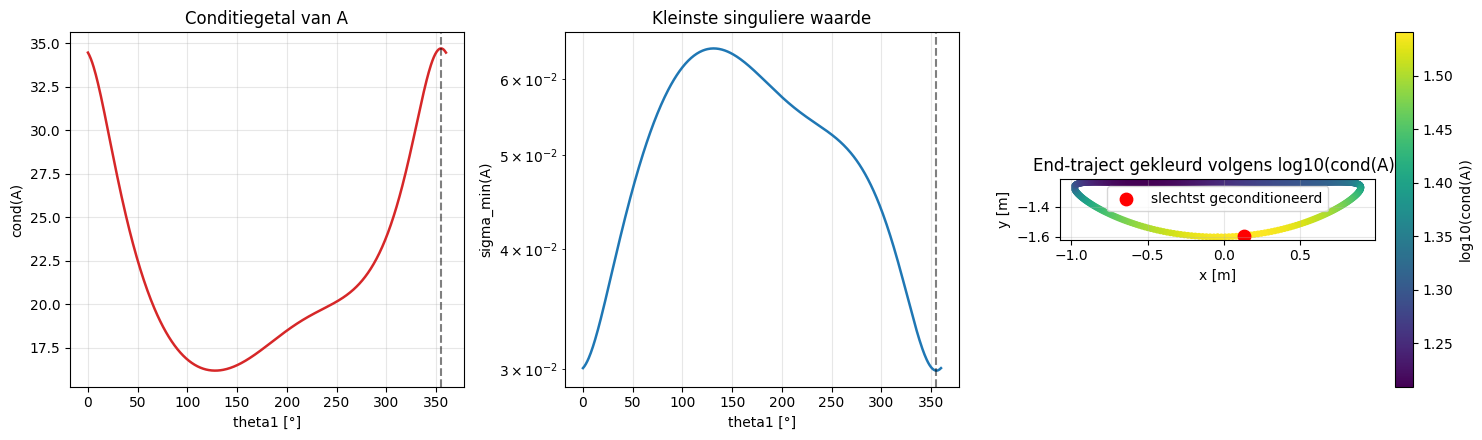

Slechtst geconditioneerde stap: k=493, theta1=355.0°, cond(A)=3.47e+01


In [75]:
# Bron: singulariteitenpatroon uit bestaand 01-notebook (cel 34 van de backup) +
# Linkage_Project (3).ipynb (geen expliciete singulariteit-cel, dus het patroon
# is volledig overgenomen uit het backup-notebook).

cond_J = np.zeros(n_t)
sigma_min = np.zeros(n_t)

for k in range(n_t):
    th1 = theta1_arr[k]
    th2, th3, th4, th5, th6, th7 = angles[k]
    A_mat = np.array([
        [ r2*np.sin(th2), 0.0, -l41*np.sin(th4), 0.0, 0.0, 0.0],
        [-r2*np.cos(th2), 0.0,  l41*np.cos(th4), 0.0, 0.0, 0.0],
        [0.0, -r3*np.sin(th3), -(l41+l42)*np.sin(th4),  l51*np.sin(th5), 0.0, 0.0],
        [0.0,  r3*np.cos(th3),  (l41+l42)*np.cos(th4), -l51*np.cos(th5), 0.0, 0.0],
        [0.0, -r3*np.sin(th3), 0.0, -l52*np.sin(th5),  r6*np.sin(th6), -l71*np.sin(th7)],
        [0.0,  r3*np.cos(th3), 0.0,  l52*np.cos(th5), -r6*np.cos(th6),  l71*np.cos(th7)],
    ])
    sv = np.linalg.svd(A_mat, compute_uv=False)
    cond_J[k] = sv[0] / sv[-1]
    sigma_min[k] = sv[-1]

worst = int(np.argmax(cond_J))

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
axs[0].plot(np.rad2deg(theta1_arr), cond_J, color='tab:red', lw=1.8)
axs[0].axvline(np.rad2deg(theta1_arr[worst]), ls='--', color='black', alpha=0.5)
axs[0].set_xlabel('theta1 [°]'); axs[0].set_ylabel('cond(A)')
axs[0].set_title('Conditiegetal van A'); axs[0].grid(True, alpha=0.3)

axs[1].semilogy(np.rad2deg(theta1_arr), sigma_min, color='tab:blue', lw=1.8)
axs[1].axvline(np.rad2deg(theta1_arr[worst]), ls='--', color='black', alpha=0.5)
axs[1].set_xlabel('theta1 [°]'); axs[1].set_ylabel('sigma_min(A)')
axs[1].set_title('Kleinste singuliere waarde'); axs[1].grid(True, alpha=0.3)

sc = axs[2].scatter(End_path[:,0], End_path[:,1], c=np.log10(cond_J), cmap='viridis', s=15)
axs[2].scatter(End_path[worst,0], End_path[worst,1], color='red', s=80, label='slechtst geconditioneerd')
axs[2].set_aspect('equal'); axs[2].grid(True, alpha=0.3)
axs[2].set_xlabel('x [m]'); axs[2].set_ylabel('y [m]')
axs[2].set_title('End-traject gekleurd volgens log10(cond(A))')
axs[2].legend()
plt.colorbar(sc, ax=axs[2], label='log10(cond(A))')

plt.tight_layout(); plt.show()
print(f'Slechtst geconditioneerde stap: k={worst}, theta1={np.rad2deg(theta1_arr[worst]):.1f}°, cond(A)={cond_J[worst]:.2e}')


## 14. Toepassing: het "touwbeest"

Het mechanisme is ontworpen voor een **vierpotige loopmachine** die zich voortbeweegt door zich met de armen aan een touw vast te haken — vandaar de werknaam *touwbeest* (verwijzing naar Theo Jansens *strandbeest*).

**Loopcyclus** Per cyclus heeft de voet $End$ twee fasen:

- **Werkstreek (`work stroke`)**: $End$ beweegt langs het *vlakke onderste* deel van de baan. Tijdens deze fase grijpt de "voet" het touw vast en duwt het mechanisme er zich tegen af → een horizontale reactiekracht in de bewegingsrichting van het lichaam.
- **Zwaaifase (`swing`)**: $End$ beweegt langs het *bovenste, ronde* deel van de baan. Geen contact met het touw, alleen zwaartekracht werkt nog op de delen.

**Vier benen, twee fases** Bij een viervoetige Chebyshev-walker is het standaard om diagonaal tegenoverliggende benen **in fase** te laten werken, en de andere twee **180° verschoven**. Daardoor is altijd minstens één diagonaal in werkstreek-fase, wat een stabiele voortgang geeft. Concreet:

- benen Linksvoor + Rechtsachter: fase $\theta_1$
- benen Rechtsvoor + Linksachter: fase $\theta_1 + \pi$

Dit wordt verder uitgewerkt in `02_stangen_inverse_dynamica.ipynb`, waar we de aandrijfmomenten berekenen en de werkstreek-belasting modelleren.

**Volgende stap.** In `02_stangen_inverse_dynamica.ipynb` voegen we toe:

- massamodel per stang (uniforme staaf, $m = \rho L$);
- zwaartekracht;
- werkstreek-belasting (horizontale reactiekracht in $-x$ tijdens werkstreek);
- inverse dynamica: berekening van het aandrijfmoment $M_A$ op de inputkruk.
